# Modeling Logistic Growth with SINDy

Consider the following generalized growth equation (needs a better name):

$$
\dot x = r_0 x(1-\rho_1 x - \rho_2 x^2 - \ldots - \rho_n x^n)
$$

With $(\rho_n)_{n \geq 1}$ a sequence of non-negative real numbers.

Our goal is to:
1) Create some sample data points of the model
2) Train a UDE on the data points
3) Apply SINDy on extra data points created from the trained UDE

In [128]:
from torch import nn
import torch 
import pysindy as ps
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt 
from torchdiffeq import odeint
from sr3_modified import my_SR3 as SR3

[0.    0.25  0.1   0.001 1.   ]


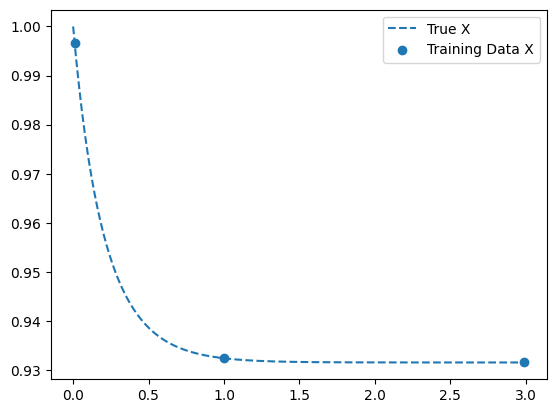

In [ ]:
# Step 1: generate model and get a sampling of its data

k = 6
rho0 = 1
rho = np.array(
    [0, 0.25, 0.1, 0.001, 1]
)

print(rho)

def generalised_growth(t, data, k, rho):
    x = data[0]
    powers = np.arange(1, k)
    x_pow = np.power(x, powers)

    return np.array(
        [rho0 * x * (1 - np.dot(x_pow, rho)) ]
    )


sol = solve_ivp(generalised_growth, t_span = [0, 3], args= (k, rho), y0 = [1], rtol=1e-9, atol=1e-9, dense_output=True, t_eval=np.arange
                (0,3, 0.01))
data = sol.y

T = sol.t
X = data[0]

plt.plot(T, X, "--", label="True X")


T_train = T[[1,100,-1]]
X_train = X[[1,100, -1]]
plt.scatter(T_train, X_train, label="Training Data X")


plt.legend()

plt.show()

In [132]:
model_old = ps.SINDy(
    feature_library=ps.PolynomialLibrary(k, include_bias=False),
    optimizer=SR3(initial_guess=np.array([1, 0, 0, 0, 0, 0]).reshape(1,6), max_iter=10000, verbose=True)
)
model_old.fit(X_train, T_train, feature_names=['x'])


 Iteration ... |y - Xw|^2 ...  |w-u|^2/v ...       R(u) ... Total Error: |y-Xw|^2 + |w-u|^2/v + R(u)
         0 ... 2.0843e-02 ... 0.0000e+00 ... 3.0000e-02 ... 5.0843e-02
         1 ... 6.5562e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.6556e-02
         2 ... 6.2580e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.6258e-02
         3 ... 6.0460e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.6046e-02
         4 ... 5.8512e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.5851e-02
         5 ... 5.6720e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.5672e-02
         6 ... 5.5072e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.5507e-02
         7 ... 5.3556e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.5356e-02
         8 ... 5.2161e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.5216e-02
         9 ... 5.0878e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.5088e-02
        10 ... 4.9697e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.4970e-02
        11 ... 4.8611e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.4861e-02
        12 ... 4.7612e-03 ... 0.0000e+00 ... 3.

c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\utils\_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


,optimizer,my_SR3(initia... verbose=True)
,feature_library,PolynomialLib...de_bias=False)
,differentiation_method,FiniteDifference()
,degree,6
,include_interaction,True
,interaction_only,False
,include_bias,False
,order,'C'
,reg_weight_lam,0.005
,regularizer,'L0'
,relax_coeff_nu,1.0


In [144]:
model_old.coefficients()

array([[ 0.65519411, -0.29514873, -0.24813263, -0.20363662, -0.        ,
        -0.        ]])

In [54]:
# Step 2. Create UDE of type x NN(x) and make it learn...

class ude_generalised_growth(nn.Module):
    def __init__(self, rho0):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 10),
            nn.Tanh(),
            nn.Linear(10, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 10),
            nn.Tanh(),
            nn.Linear(10, 1)
        ) 

    def forward(self, t, x):
        return x * (self.net(x))

In [76]:
from tqdm import tqdm 
my_growth = ude_generalised_growth(rho0)

lr = 0.01
optimizer = torch.optim.Adam(my_growth.parameters(), lr=lr)
n_epochs = 1000
SKIP = 4

rtol = 1e-7
losses = []

t_train_torch = torch.tensor(T_train, dtype=torch.float32)
x0_torch = torch.tensor([1], dtype=torch.float32, requires_grad=True)
x_train_torch = torch.tensor(X_train, dtype=torch.float32).view(-1, 1)

for EPOCH in tqdm(range(n_epochs)):
    optimizer.zero_grad()
    
    # forward solution
    x_pred = odeint(my_growth, 
                    x0_torch,
                    t_train_torch,
                    method="dopri5",
                    rtol=1e-7,
                    atol=1e-7
                    )
    
    # Compute loss at training points
    loss = torch.mean(torch.pow(x_pred-x_train_torch, 2))
    
    # Backpropagate
    loss.backward()
    optimizer.step()
    
    with torch.no_grad():
        losses += [loss]

100%|██████████| 1000/1000 [02:17<00:00,  7.25it/s]


In [101]:
torch.save(my_growth.state_dict(), "./models_weights/growth_ude.dm")

In [49]:
my_growth = ude_generalised_growth(rho0)
my_growth.load_state_dict(torch.load("./models_weights/growth_ude.dm"))

<All keys matched successfully>

In [117]:
losses_np = []
for loss in losses:
    losses_np.append(loss.item())

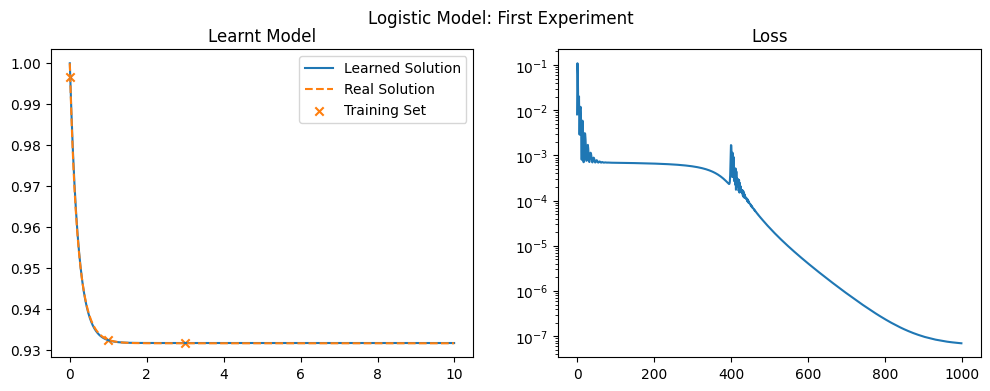

In [124]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x_pred = odeint(my_growth, 
                torch.tensor([1.], requires_grad=True),
                T_torch := torch.arange(0, 10, 0.01)
                )

axes[0].plot(T_torch, x_pred.detach().numpy(), label="Learned Solution")

sol = solve_ivp(generalised_growth, t_span = [0, 10], args= (k, rho), y0 = [1], rtol=1e-9, atol=1e-9, dense_output=True, t_eval=np.arange
                (0,10, 0.01))
data = sol.y

T = sol.t
X = data[0]

axes[0].plot(T, X, "--", label="Real Solution")
axes[0].scatter([], [])
axes[0].scatter(T_train, X_train, marker="x", label="Training Set")
axes[0].set_title("Learnt Model")
axes[0].legend()

axes[1].set_title("Loss")
axes[1].semilogy(losses_np)

plt.suptitle("Logistic Model: First Experiment")

plt.show()

In [123]:
losses[-1]

tensor(6.9468e-08, grad_fn=<MeanBackward0>)

 Iteration ... |y - Xw|^2 ...  |w-u|^2/v ...       R(u) ... Total Error: |y-Xw|^2 + |w-u|^2/v + R(u)
         0 ... 2.6221e-02 ... 0.0000e+00 ... 3.0000e-02 ... 5.6221e-02
         1 ... 8.9386e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.8939e-02
         2 ... 8.1494e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.8149e-02
         3 ... 7.4967e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.7497e-02
         4 ... 6.8966e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.6897e-02
         5 ... 6.3445e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.6345e-02
         6 ... 5.8366e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.5837e-02
         7 ... 5.3694e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.5369e-02
         8 ... 4.9396e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.4940e-02
         9 ... 4.5442e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.4544e-02
        10 ... 4.1804e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.4180e-02
        11 ... 3.8458e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.3846e-02
        12 ... 3.5379e-03 ... 0.0000e+00 ... 3.

c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\utils\_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\utils\_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


,optimizer,my_SR3(initia... verbose=True)
,feature_library,PolynomialLib...de_bias=False)
,differentiation_method,FiniteDifference(axis=-2)
,degree,6
,include_interaction,True
,interaction_only,False
,include_bias,False
,order,'C'
,reg_weight_lam,0.005
,regularizer,'L0'
,relax_coeff_nu,1.0


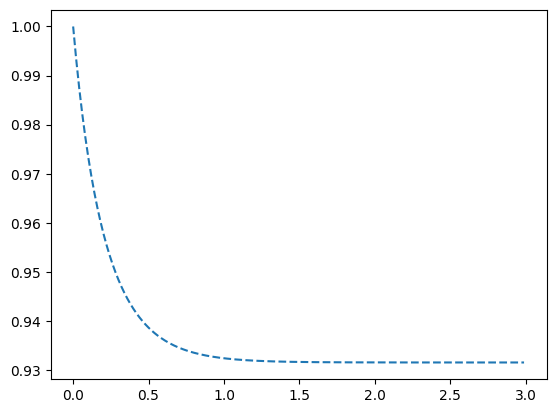

In [133]:
# Now... train SINDy with the new derivatives

# recover data
sol = solve_ivp(generalised_growth, t_span = [0, 3], args= (k, rho), y0 = [1], rtol=1e-9, atol=1e-9, dense_output=True, t_eval=np.arange
                (0,3, 0.01))
data = sol.y

T = sol.t
X = data[0]

plt.plot(T, X, "--", label="True X")


T_train = torch.tensor(T[[1,100, -1]])
X_train = torch.tensor(X[[1,100, -1]], dtype=torch.float32)

X_dot = torch.zeros(T_train.shape[0])

for i, (t, x) in enumerate(zip(T_train, X_train)):
    X_dot[i] = my_growth(t, torch.tensor([x], dtype=torch.float32))


model = ps.SINDy(
    feature_library=ps.PolynomialLibrary(k, include_bias=False),
    optimizer=SR3(initial_guess=np.array([1, 0, 0, 0, 0, 0]).reshape(1,6), max_iter=10000, verbose=True)
)

model.fit(X_train.detach().numpy(), T_train.detach().numpy(), feature_names=['x'], x_dot=X_dot.detach().numpy())

c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\utils\_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\utils\_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


 Iteration ... |y - Xw|^2 ...  |w-u|^2/v ...       R(u) ... Total Error: |y-Xw|^2 + |w-u|^2/v + R(u)
         0 ... 2.2222e-02 ... 0.0000e+00 ... 3.0000e-02 ... 5.2222e-02
         1 ... 1.6833e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.6833e-02
         2 ... 1.4284e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.4284e-02
         3 ... 1.2126e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.2126e-02
         4 ... 1.0299e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.0299e-02
         5 ... 8.7508e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.8751e-02
         6 ... 7.4401e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.7440e-02
         7 ... 6.3302e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.6330e-02
         8 ... 5.3903e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.5390e-02
         9 ... 4.5943e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.4594e-02
        10 ... 3.9202e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.3920e-02
        11 ... 3.3494e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.3349e-02
        12 ... 2.8660e-03 ... 0.0000e+00 ... 3.

c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\optimizers\sr3.py:374: ConvergenceWarning: SR3 did not converge after 10000 iterations.
  warnings.warn(


,optimizer,my_SR3(initia... verbose=True)
,feature_library,PolynomialLib...de_bias=False)
,differentiation_method,FiniteDifference(axis=-2)
,degree,6
,include_interaction,True
,interaction_only,False
,include_bias,False
,order,'C'
,reg_weight_lam,0.005
,regularizer,'L0'
,relax_coeff_nu,1.0


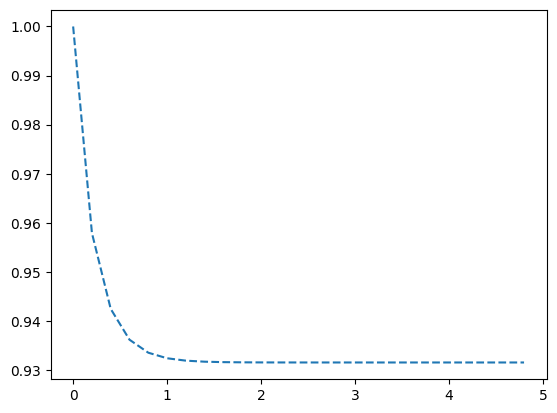

In [134]:
# Now... train SINDy with the new derivatives

# recover data
sol = solve_ivp(generalised_growth, t_span = [0, 5], args= (k, rho), y0 = [1], rtol=1e-9, atol=1e-9, dense_output=True, t_eval=np.arange
                (0,5, 0.2))
data = sol.y

T = sol.t
X = data[0]

plt.plot(T, X, "--", label="True X")


# we use lots of data instead
T_train = T
X_train = X

X_dot = torch.zeros(T_train.shape[0])

for i, (t, x) in enumerate(zip(T_train, X_train)):
    X_dot[i] = my_growth(t, torch.tensor([x], dtype=torch.float32))


model_lots = ps.SINDy(
    feature_library=ps.PolynomialLibrary(k, include_bias=False),
    optimizer=SR3(initial_guess=np.array([1, 0, 0, 0, 0, 0]).reshape(1,6), max_iter=10000, verbose=True)
)

model_lots.fit(X_train, T_train, feature_names=['x'], x_dot=X_dot.detach().numpy())

In [135]:
model.coefficients()

array([[ 1.03533981,  0.        , -0.19315172, -0.29528856, -0.39005679,
        -0.47804018]])

In [136]:
model_lots.coefficients()

array([[ 1.2342583 , -0.        , -0.41431501, -0.48955045, -0.42268057,
        -0.22973006]])

In [137]:
#     [1, 0, 0.25, 0.1, 0.001, 1]

In [138]:
def poly_sindy(x, deg, model):
    p = np.zeros(deg)
    p[1:] = model.coefficients()

    p = p[::-1]

    return np.polyval(p, x)

def poly_real(x, deg):
    p = np.zeros(deg)

    p[1] = 1

    p[2:] = -rho0 * rho.reshape(deg-2)

    p = p[::-1]

    return np.polyval(p, x)

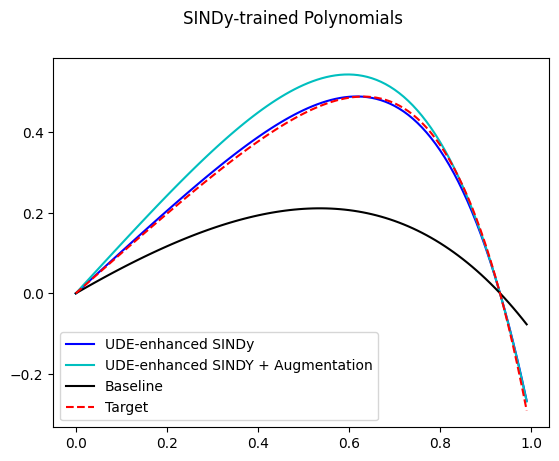

In [143]:
plt.plot(np.arange(0, 1, 0.01), poly_sindy(np.arange(0, 1, 0.01), k+1, model), "b", label="UDE-enhanced SINDy")
plt.plot(np.arange(0, 1, 0.01), poly_sindy(np.arange(0, 1, 0.01), k+1, model_lots), "c", label="UDE-enhanced SINDY + Augmentation")
plt.plot(np.arange(0, 1, 0.01), poly_sindy(np.arange(0, 1, 0.01), k+1, model_old), "k", label="Baseline")
plt.plot(np.arange(0, 1, 0.01), poly_real(np.arange(0, 1, 0.01), k+1), "r--", label="Target")
plt.suptitle("SINDy-trained Polynomials")
plt.legend()

In [140]:
from scipy.integrate import quad

In [141]:
def poly_diff1(x):
    return (poly_sindy(x, k+1, model)-poly_real(x, k+1))**2

def poly_diff2(x):
    return (poly_sindy(x, k+1, model_old)-poly_real(x, k+1))**2


def poly_diff3(x):
    return (poly_sindy(x, k+1, model_lots)-poly_real(x, k+1))**2

print("L2 Erorr in [0,1] before data augmentation with UDEs:\t", quad(poly_diff2, 0, 1),"\nL2 Error after:\t",
quad(poly_diff1, 0, 1),"\nL2 Error after (with more data):\t", quad(poly_diff3, 0,1))

L2 Erorr in [0,1] before data augmentation with UDEs:	 (0.03593026242180781, 3.9890604621515067e-16) 
L2 Error after:	 (8.052065386473705e-05, 8.939588387850366e-19) 
L2 Error after (with more data):	 (0.0021354262664575515, 2.3707994084105084e-17)
